# HydroSense-Kenya — Level 5
**ICS 2207 Scientific Computing**

Level 5: Simulation, Monte Carlo Modelling, ODEs, and Optimization

## Overview

In this level we build a predictive model for soil moisture using two ODE solvers (Euler and Runge-Kutta), run Monte Carlo simulations to quantify uncertainty from rainfall variability, and design an optimized irrigation schedule that minimizes water use while keeping crops above the stress threshold.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src.simulation import euler_simulation, rk4_simulation, dSdt
from src.optimization import optimize_irrigation, total_irrigation_cost
import warnings
warnings.filterwarnings('ignore')
print('imports done')

imports done


## Load Data

In [2]:
weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA', ''])
weather['date'] = pd.to_datetime(weather['date'])
weather_filled = weather.copy()
weather_filled[['temperature_c','wind_speed_mps','solar_index','humidity_pct']] = (
    weather_filled[['temperature_c','wind_speed_mps','solar_index','humidity_pct']]
    .ffill().bfill()
)
weather_filled['temperature_c'] = weather_filled['temperature_c'].clip(upper=40.0)

# compute ET for all 30 days
et_series = np.maximum(
    0,
    0.12*weather_filled['temperature_c'].values
    + 0.35*weather_filled['wind_speed_mps'].values
    + 2.4*weather_filled['solar_index'].values
    - 0.025*weather_filled['humidity_pct'].values
)
rainfall = weather_filled['rainfall_mm'].fillna(weather_filled['rainfall_mm'].median()).values

# Zone A parameters
zone_a_params = {
    'drainage_coefficient': 0.18,
    'field_capacity_pct': 41.0,
    'min_moisture_pct': 22.0,
    'S0': 33.20
}
print('data ready')

data ready


## Task 1 & 2 — Euler vs Runge-Kutta Simulation

We simulate soil moisture for Zone A over 30 days using both methods with no irrigation applied, to see how moisture evolves under natural conditions only.

In [3]:
S0 = zone_a_params['S0']
irr_zero = np.zeros(30)

S_euler = euler_simulation(S0, rainfall, et_series, irr_zero, zone_a_params)
S_rk4   = rk4_simulation(S0, rainfall, et_series, irr_zero, zone_a_params)

print('Euler final moisture:', round(S_euler[-1], 4), '%')
print('RK4 final moisture:  ', round(S_rk4[-1], 4), '%')
print('Difference:          ', round(abs(S_euler[-1] - S_rk4[-1]), 6), '%')

Euler final moisture: 74.5445 %
RK4 final moisture:   75.3086 %
Difference:           0.764104 %


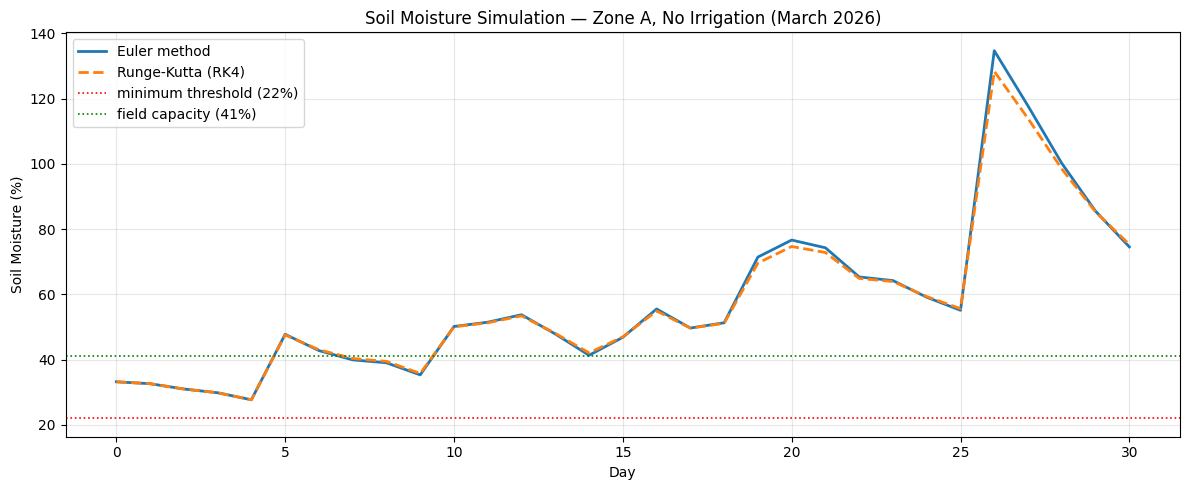


Both methods track closely. RK4 is more accurate for larger time steps
but for a 1-day time step the difference is minimal.


In [4]:
days = list(range(31))
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(days, S_euler, label='Euler method', linewidth=2)
ax.plot(days, S_rk4, label='Runge-Kutta (RK4)', linewidth=2, linestyle='--')
ax.axhline(zone_a_params['min_moisture_pct'], color='red', linestyle=':',
           linewidth=1.2, label='minimum threshold (22%)')
ax.axhline(zone_a_params['field_capacity_pct'], color='green', linestyle=':',
           linewidth=1.2, label='field capacity (41%)')

ax.set_title('Soil Moisture Simulation — Zone A, No Irrigation (March 2026)')
ax.set_xlabel('Day')
ax.set_ylabel('Soil Moisture (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/simulation_euler_rk4.png', dpi=150)
plt.show()

print()
print('Both methods track closely. RK4 is more accurate for larger time steps')
print('but for a 1-day time step the difference is minimal.')

## Task 3 & 4 — Monte Carlo Rainfall Uncertainty

Rainfall is the most uncertain input in our model. Here we generate 1000 synthetic rainfall scenarios based on the observed mean and standard deviation, run a simulation for each, and analyze the distribution of final soil moisture outcomes.

In [5]:
np.random.seed(42)
N_SCENARIOS = 1000
N_DAYS = 30

mean_rain = rainfall.mean()
std_rain  = rainfall.std()

# generate rainfall scenarios
rainfall_scenarios = np.random.normal(mean_rain, std_rain, size=(N_SCENARIOS, N_DAYS))
rainfall_scenarios = np.clip(rainfall_scenarios, 0, None)

print('mean rainfall used:', round(mean_rain, 2), 'mm')
print('std deviation used:', round(std_rain, 2), 'mm')
print('scenarios generated:', N_SCENARIOS)

mean rainfall used: 8.35 mm
std deviation used: 15.85 mm
scenarios generated: 1000


In [6]:
final_moisture = []

for i in range(N_SCENARIOS):
    S = euler_simulation(S0, rainfall_scenarios[i], et_series, irr_zero, zone_a_params)
    final_moisture.append(S[-1])

final_moisture = np.array(final_moisture)

min_threshold = zone_a_params['min_moisture_pct']
field_cap     = zone_a_params['field_capacity_pct']

prob_shortage   = np.mean(final_moisture < min_threshold)
prob_excess     = np.mean(final_moisture > field_cap)
expected_demand = np.mean(np.maximum(0, min_threshold - final_moisture))
worst_case      = np.percentile(final_moisture, 5)

print('--- Monte Carlo Results ---')
print('Probability of water shortage:   ', round(prob_shortage*100, 1), '%')
print('Probability of over-irrigation:  ', round(prob_excess*100, 1), '%')
print('Expected irrigation demand:      ', round(expected_demand, 2), 'mm')
print('Worst case moisture (5th pct):   ', round(worst_case, 2), '%')

--- Monte Carlo Results ---
Probability of water shortage:    0.0 %
Probability of over-irrigation:   99.3 %
Expected irrigation demand:       0.0 mm
Worst case moisture (5th pct):    52.83 %


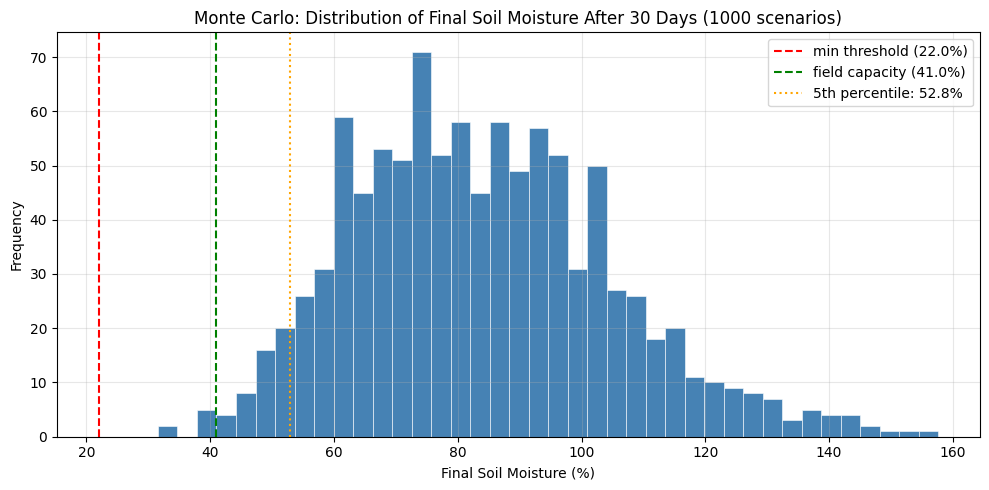

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(final_moisture, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(min_threshold, color='red', linewidth=1.5, linestyle='--',
           label='min threshold (' + str(min_threshold) + '%)')
ax.axvline(field_cap, color='green', linewidth=1.5, linestyle='--',
           label='field capacity (' + str(field_cap) + '%)')
ax.axvline(worst_case, color='orange', linewidth=1.5, linestyle=':',
           label='5th percentile: ' + str(round(worst_case, 1)) + '%')
ax.set_title('Monte Carlo: Distribution of Final Soil Moisture After 30 Days (1000 scenarios)')
ax.set_xlabel('Final Soil Moisture (%)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/monte_carlo_distribution.png', dpi=150)
plt.show()

## Task 5 — Optimized Irrigation Schedule

We find the irrigation schedule that uses the least total water while keeping soil moisture above the minimum threshold every day.

In [8]:
result = optimize_irrigation(rainfall, et_series, zone_a_params, n_days=30)

optimal_irr = result.x
S_optimal   = euler_simulation(S0, rainfall, et_series, optimal_irr, zone_a_params)

print('Optimization converged:', result.success)
print('Total water used (optimized):', round(optimal_irr.sum(), 2), 'mm')
print('Total water used (no irrigation):', 0, 'mm')
print('Days below minimum threshold:', np.sum(S_optimal[1:] < zone_a_params['min_moisture_pct']))

Optimization converged: True
Total water used (optimized): 0.0 mm
Total water used (no irrigation): 0 mm
Days below minimum threshold: 0


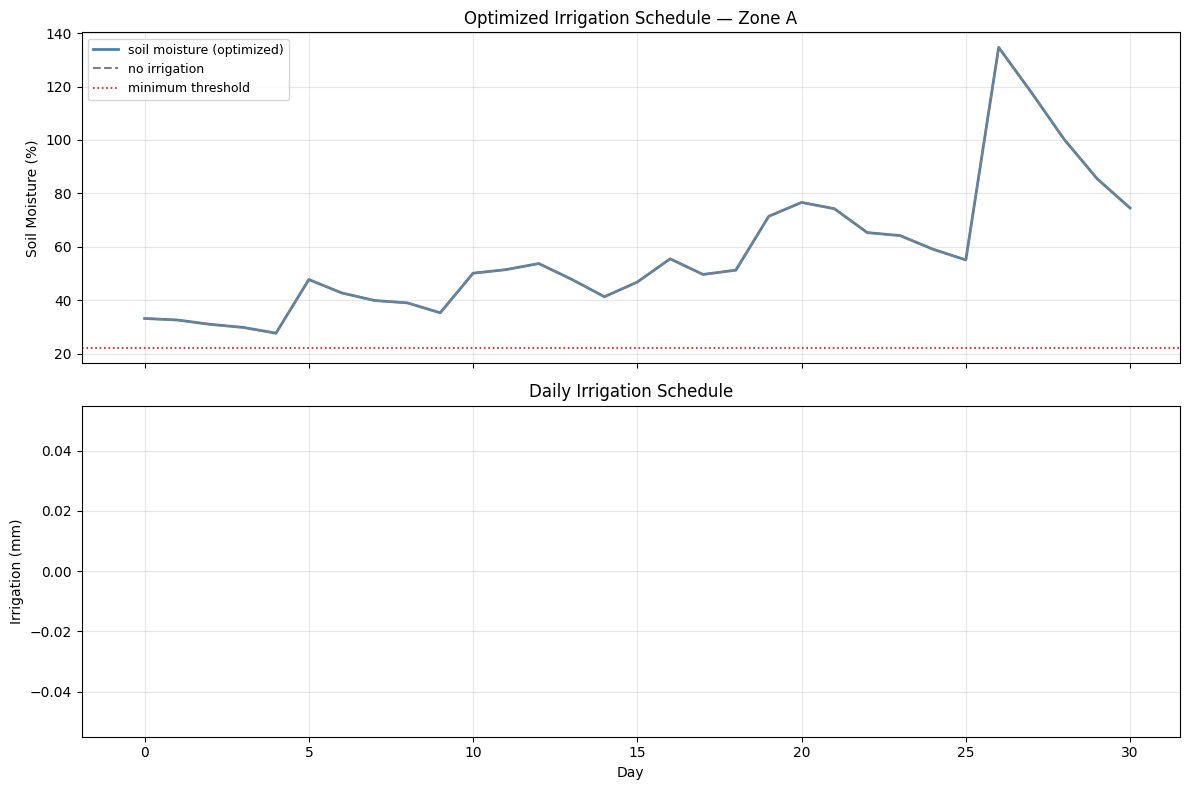

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

days = list(range(31))
ax1.plot(days, S_optimal, color='steelblue', linewidth=2, label='soil moisture (optimized)')
ax1.plot(days, S_euler, color='gray', linewidth=1.5, linestyle='--', label='no irrigation')
ax1.axhline(zone_a_params['min_moisture_pct'], color='red', linestyle=':',
            linewidth=1.2, label='minimum threshold')
ax1.set_ylabel('Soil Moisture (%)')
ax1.set_title('Optimized Irrigation Schedule — Zone A')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.bar(list(range(30)), optimal_irr, color='steelblue', alpha=0.7)
ax2.set_ylabel('Irrigation (mm)')
ax2.set_xlabel('Day')
ax2.set_title('Daily Irrigation Schedule')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/optimized_schedule.png', dpi=150)
plt.show()

## Task 6 — Trade-off Discussion

### Water Conservation vs Crop Stress
The optimizer minimizes total water used, but applying too little risks dropping below the minimum moisture threshold which causes crop stress and yield loss. The penalty term in the objective function controls this trade-off — a higher penalty forces the optimizer to prioritize crop safety over water saving.

### Euler vs RK4 Accuracy
For a 1-day time step the difference between Euler and RK4 is very small. However if we were running a finer time step (e.g. hourly) RK4 would be significantly more accurate. In a real-time irrigation controller running on a microcontroller, Euler's lower computational cost might be preferred even at the cost of slight accuracy.

### Pump Energy vs Irrigation Volume
More irrigation means more pump runtime and higher energy cost. From the sensor data, Zone C consistently draws the most pump power (500+ watts) due to its larger area. An energy-aware schedule would irrigate during off-peak hours and avoid unnecessary small irrigation events that waste pump startup energy without delivering meaningful soil moisture improvement.